## Welfare Bot - Linear Regression Analysis

Tässä notebookissa käytän lineaarista regressiota ennustamaan käyttäjän overall_score-arvoa ja analysoimaan, mitkä hyvinvointimittarit vaikuttavat siihen eniten.

In [44]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split # data splitataan koulutus- ja testijoukkoihin, jotta voidaan 
                                                     # arvioida mallin suorituskykyä
from sklearn.linear_model import LinearRegression    # lineaarinen regressio on yksinkertainen malli, joka sopii hyvin tähän dataan, 
                                                     # koska haluamme ymmärtää, miten eri tekijät vaikuttavat kokonaisvaltaiseen hyvinvointiin
from sklearn.metrics import mean_absolute_error, r2_score  # Mean Absolute Error (MAE) mittaa mallin ennusteiden keskimääräistä poikkeamaa 
                                                     # todellisista arvoista, ja R² kertoo, kuinka hyvin malli selittää datan vaihtelua

In [45]:
data = pd.read_csv("../data/welfare_bot_metrics_cleaned.csv") # luetaan data CSV-tiedostosta pandas DataFrameen, 
                                                              #  jotta voimme analysoida ja visualisoida sitä

data.head()

,date,user_name,email,mood_score,sleep_score,food_score,hydration_score,medication_score,social_score,overall_score,risk_level
0,2025-01-01,Aino Mäkinen,aino.makinen@demo.fi,4.40,3.94,2.99,1.00,0.88,3.38,8.890,low
1,2025-01-02,Aino Mäkinen,aino.makinen@demo.fi,4.83,4.31,2.66,0.96,0.86,3.27,8.980,low
2,2025-01-03,Aino Mäkinen,aino.makinen@demo.fi,4.30,3.24,2.28,0.80,0.82,3.66,7.670,low
3,2025-01-04,Aino Mäkinen,aino.makinen@demo.fi,3.84,3.44,3.00,0.79,0.91,2.79,7.765,NaN
4,2025-01-05,Aino Mäkinen,aino.makinen@demo.fi,3.99,4.05,2.46,0.94,0.85,3.36,8.250,low


## Missing values handling

Poistan rivit, joissa on puuttuvia arvoja, koska lineaarinen regressio ei pysty käsittelemään NaN-arvoja.

In [46]:
data = data.dropna()
data.isnull().sum()

date                0
user_name           0
email               0
mood_score          0
sleep_score         0
food_score          0
hydration_score     0
medication_score    0
social_score        0
overall_score       0
risk_level          0
dtype: int64

## Feature selection

Valitsen hyvinvointimittarit selittäviksi muuttujiksi ja overall_score-arvon ennustettavaksi muuttujaksi.

In [47]:
features = [
    "mood_score",
    "sleep_score",
    "food_score",
    "hydration_score",
    "medication_score",
    "social_score"
]

X = data[features]

y = data["overall_score"]

## Datan jakaminen

Jaan datan training- ja testidataan, jotta voin arvioida mallin suorituskykyä uudella datalla.

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # 20% datasta testijoukkoon, jotta voimme arvioida mallin suorituskykyä uudella datalla, jota malli ei ole nähnyt koulutuksen aikana
    random_state=42 # asetetaan random_state, jotta data splitataan samaan tapaan joka kerta, mikä tekee tuloksista vertailukelpoisia
)

## Train model

Koulutan lineaarisen regressiomallin training-datalla. Malli oppii, miten eri hyvinvointitekijät yhdessä vaikuttavat overall_score-arvoon.

In [49]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Predictions

Käytän koulutettua mallia ennustamaan testidatan overall_score-arvot ja vertaan ennusteita todellisiin arvoihin.

In [50]:
predictions = model.predict(X_test)

## Evaluation

Arvioin mallin suorituskykyä kahdella mittarilla:
- MAE kertoo keskimääräisen ennustevirheen
- R² kertoo, kuinka hyvin malli selittää datan vaihtelua

In [51]:
mae = mean_absolute_error(y_test, predictions) # MAE mittaa mallin ennusteiden keskimääräistä poikkeamaa todellisista 
                                               # arvoista, ja pienempi MAE tarkoittaa parempaa mallia

r2 = r2_score(y_test, predictions) # R² kertoo, kuinka hyvin malli selittää datan vaihtelua, ja se on välillä 0-1,
                                   # jossa 1 tarkoittaa täydellistä selitystä ja 0 tarkoittaa, että malli ei selitä 
                                   # lainkaan datan vaihtelua

print(f"Model MAE: {mae:.2f}")
print(f"Model R² score: {r2:.2f}")

Model MAE: 0.01
Model R² score: 1.00


## Mallin arviointi

MAE-arvo kertoo, kuinka tarkasti malli ennustaa, ja R² näyttää, kuinka suuren osan hyvinvoinnin vaihtelusta malli pystyy selittämään.

## Feature importance

Tarkastelen, mitkä hyvinvointimittarit vaikuttavat eniten overall_score-arvoon. Suurempi kerroin tarkoittaa voimakkaampaa vaikutusta.

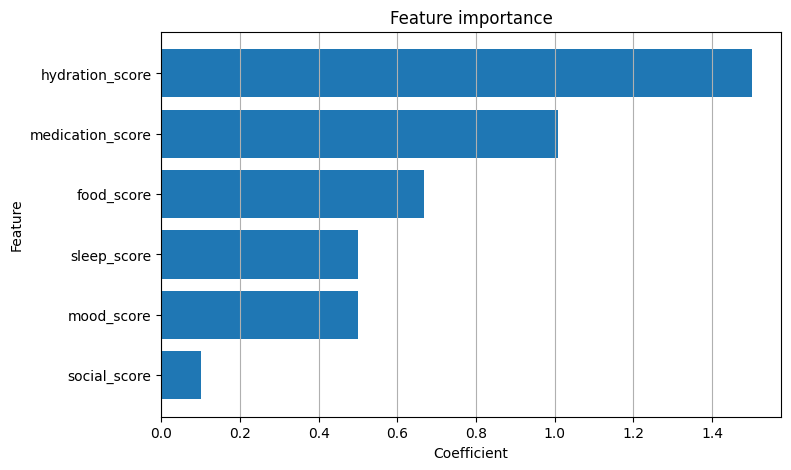

In [52]:
importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

importance = importance.sort_values("Coefficient", ascending=True)
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Coefficient"]
)

plt.title("Feature importance")

plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.grid(axis="x")

plt.show()

## Feature importance analysointi

Voimakkaimmin overall_score-arvoon vaikuttivat hydration_score, medication_score ja food_score, eli perustarpeet kuten nesteytys, lääkitys ja ravinto.

Sleep_score ja mood_score vaikuttivat hieman vähemmän, ja social_score sai pienimmän kertoimen sosiaalisten kontaktien vaikutukset voivat näkyä pidemmällä aikavälillä ja epäsuoremmin.

## Visualization

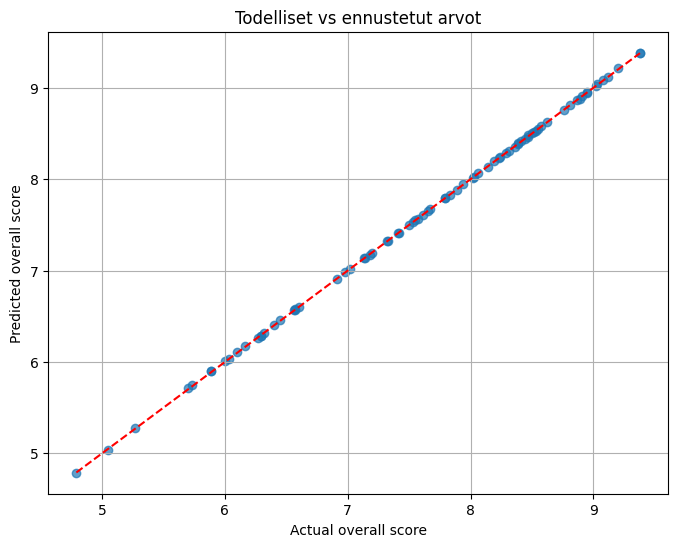

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual overall score")
plt.ylabel("Predicted overall score")

plt.title("Todelliset vs ennustetut arvot")

plt.grid()

plt.show()

## Visualisoinnin analysointi

Pisteet sijoittuivat melko lähelle diagonaalia, eli lineaarinen regressio soveltui hyvin hyvinvointidatan analysointiin.

## Residual analysis

Residual tarkoittaa mallin ennusteen ja todellisen arvon välistä eroa. Visualisoinnin avulla näen, missä tilanteissa malli tekee suurimpia virheitä.

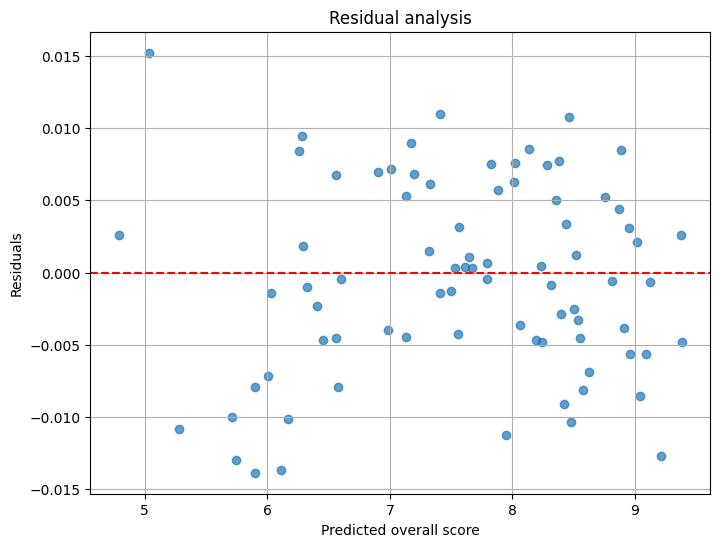

In [54]:
# Lasketaan residuals
residuals = y_test - predictions

plt.figure(figsize=(8,6))

plt.scatter(
    predictions,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted overall score")
plt.ylabel("Residuals")

plt.title("Residual analysis")

plt.grid()

plt.show()

## Residual analysis interpretation

Suurin osa residual-arvoista oli lähellä nollaa, mikä tarkoittaa, että malli ennusti hyvinvointia melko hyvin.

Suurempia poikkeamia näkyi erityisesti matalissa ja korkeissa overall_score-arvoissa, eli hyvinvointi ei riipu täysin lineaarisesti vain valituista featureista.

## Residual distribution

Tarkastelen residual-arvojen jakaumaa histogrammin avulla nähdäkseni, kuinka suuria mallin virheet yleensä ovat.

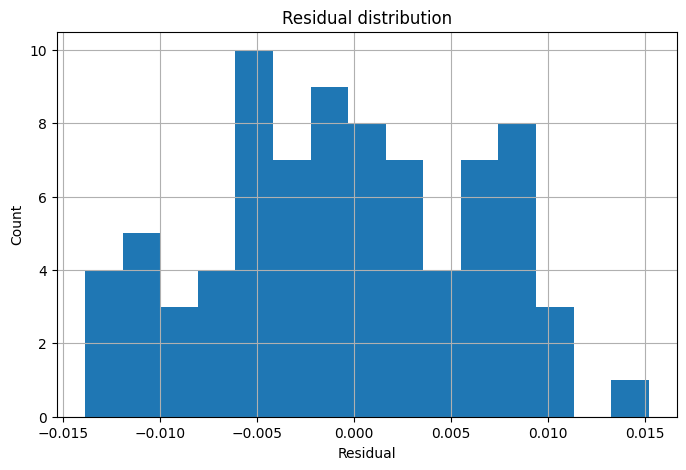

In [55]:
plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=15
)

plt.title("Residual distribution")

plt.xlabel("Residual")
plt.ylabel("Count")

plt.grid()

plt.show()

## Residual distribution interpretation

Suurin osa residual-arvoista sijoittui lähelle nollaa, eli mallin ennusteet olivat useimmiten lähellä todellisia arvoja. Suuremmat poikkeamat ovat odotettuja, koska hyvinvointiin vaikuttaa myös tekijöitä, joita mallissa ei huomioitu.

## Sosiaalisen aktiivisuuden vaikutus tulevaan hyvinvointiin

Tutkin, voiko social_score-arvon ja seuraavan päivän overall_score-arvon välillä olla yhteyttä.

In [56]:
# Shiftataan overall_score yhdellä päivällä eteenpäin,
# jotta voidaan tarkastella seuraavan päivän hyvinvointia
data["future_overall_score"] = data["overall_score"].shift(-1)

# Poistetaan rivit, joissa future_overall_score puuttuu
future_data = data.dropna(subset=["future_overall_score"])

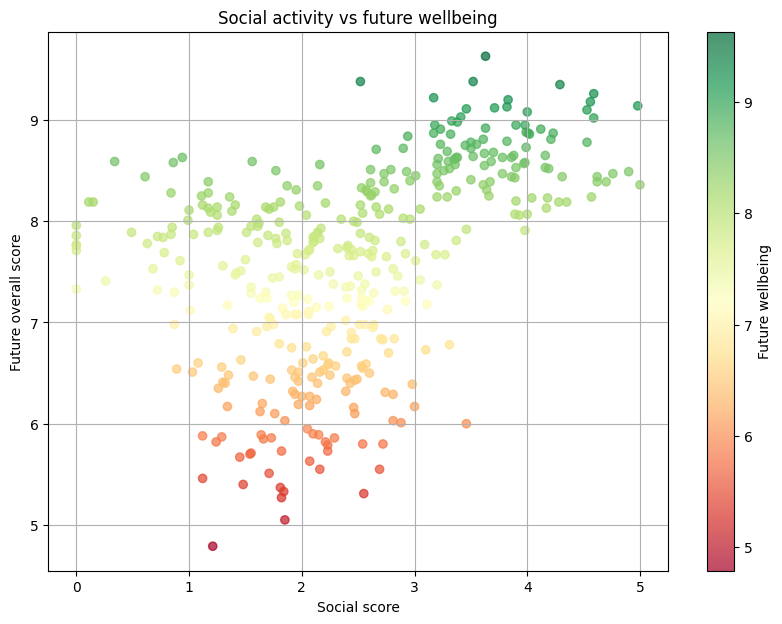

In [57]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    future_data["social_score"],
    future_data["future_overall_score"],
    c=future_data["future_overall_score"],
    cmap="RdYlGn",
    alpha=0.7
)

plt.colorbar(scatter, label="Future wellbeing")

plt.title("Social activity vs future wellbeing")

plt.xlabel("Social score")
plt.ylabel("Future overall score")

plt.grid()

plt.show()

Korkeampi social_score näytti usein liittyvän parempaan tulevaan hyvinvointiin. Tämä tukee Welfare Bot -projektin ideaa siitä, että sosiaalinen vuorovaikutus voi olla varhainen signaali hyvinvoinnin muutoksista.

## Yhteenveto

Lineaarisen regression avulla analysoin, miten eri hyvinvointimittarit vaikuttavat käyttäjän overall_score-arvoon, ja tulokset osoittivat, että erityisesti nesteytys, lääkitys, uni ja ravinto liittyivät vahvasti kokonaisvaltaiseen hyvinvointiin.